In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import seaborn as sns

In [2]:
data = pd.read_parquet(Path.cwd().parent / "data/raw/bikes.parquet")
data.head()

,counter_id,counter_name,site_id,site_name,bike_count,date,counter_installation_date,coordinates,counter_technical_id,latitude,longitude,log_bike_count
48321,100007049-102007049,28 boulevard Diderot E-O,100007049,28 boulevard Diderot,0.0,2020-09-01 02:00:00,2013-01-18,"48.846028,2.375429",Y2H15027244,48.846028,2.375429,0.000000
48324,100007049-102007049,28 boulevard Diderot E-O,100007049,28 boulevard Diderot,1.0,2020-09-01 03:00:00,2013-01-18,"48.846028,2.375429",Y2H15027244,48.846028,2.375429,0.693147
48327,100007049-102007049,28 boulevard Diderot E-O,100007049,28 boulevard Diderot,0.0,2020-09-01 04:00:00,2013-01-18,"48.846028,2.375429",Y2H15027244,48.846028,2.375429,0.000000
48330,100007049-102007049,28 boulevard Diderot E-O,100007049,28 boulevard Diderot,4.0,2020-09-01 15:00:00,2013-01-18,"48.846028,2.375429",Y2H15027244,48.846028,2.375429,1.609438
48333,100007049-102007049,28 boulevard Diderot E-O,100007049,28 boulevard Diderot,9.0,2020-09-01 18:00:00,2013-01-18,"48.846028,2.375429",Y2H15027244,48.846028,2.375429,2.302585


In [3]:
external_data = pd.read_csv(Path.cwd().parent / "data/raw/external_data.csv")

In [4]:
external_data.head()

,numer_sta,date,pmer,tend,cod_tend,dd,ff,t,td,u,...,hnuage1,nnuage2,ctype2,hnuage2,nnuage3,ctype3,hnuage3,nnuage4,ctype4,hnuage4
0,7149,2021-01-01 00:00:00,100810,80,1,270,1.8,272.75,272.15,96,...,600.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,7149,2021-01-01 03:00:00,100920,110,3,300,1.7,271.25,270.95,98,...,1500.0,2.0,3.0,3000.0,NaN,NaN,NaN,NaN,NaN,NaN
2,7149,2021-01-01 06:00:00,100950,30,3,290,2.6,271.95,271.65,98,...,480.0,4.0,6.0,2000.0,6.0,3.0,3000.0,NaN,NaN,NaN
3,7149,2021-01-01 09:00:00,101100,150,2,280,1.7,272.45,272.05,97,...,1740.0,3.0,3.0,2800.0,NaN,NaN,NaN,NaN,NaN,NaN
4,7149,2021-01-01 12:00:00,101110,30,0,50,1.0,276.95,274.15,82,...,330.0,4.0,6.0,570.0,7.0,6.0,810.0,NaN,NaN,NaN


Nos données météo sont agrégées toutes les 3h, alors que nos données de compteurs vélo sont agrégées toutes les heures

In [5]:
external_data_cleaned = external_data.apply(
    lambda col: (
        col.fillna(method="ffill").fillna(method="bfill") if col.isna().any() else col
    )
)
external_data_cleaned = external_data_cleaned.dropna(axis=1, how="any")
external_data_cleaned = external_data_cleaned.drop_duplicates(subset=["date"])
external_data_cleaned.head()


/var/folders/dr/m9v4shms079d9s6z6c8cg57m0000gn/T/ipykernel_16610/1445602811.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  lambda col: col.fillna(method='ffill').fillna(method='bfill') if col.isna().any() else col


,numer_sta,date,pmer,tend,cod_tend,dd,ff,t,td,u,...,hnuage1,nnuage2,ctype2,hnuage2,nnuage3,ctype3,hnuage3,nnuage4,ctype4,hnuage4
0,7149,2021-01-01 00:00:00,100810,80,1,270,1.8,272.75,272.15,96,...,600.0,2.0,3.0,3000.0,6.0,3.0,3000.0,7.0,9.0,7500.0
1,7149,2021-01-01 03:00:00,100920,110,3,300,1.7,271.25,270.95,98,...,1500.0,2.0,3.0,3000.0,6.0,3.0,3000.0,7.0,9.0,7500.0
2,7149,2021-01-01 06:00:00,100950,30,3,290,2.6,271.95,271.65,98,...,480.0,4.0,6.0,2000.0,6.0,3.0,3000.0,7.0,9.0,7500.0
3,7149,2021-01-01 09:00:00,101100,150,2,280,1.7,272.45,272.05,97,...,1740.0,3.0,3.0,2800.0,6.0,3.0,3000.0,7.0,9.0,7500.0
4,7149,2021-01-01 12:00:00,101110,30,0,50,1.0,276.95,274.15,82,...,330.0,4.0,6.0,570.0,7.0,6.0,810.0,7.0,9.0,7500.0


In [7]:
external_data_cleaned = external_data_cleaned.sort_values(by="date")
external_data_cleaned.head()

,numer_sta,date,pmer,tend,cod_tend,dd,ff,t,td,u,...,hnuage1,nnuage2,ctype2,hnuage2,nnuage3,ctype3,hnuage3,nnuage4,ctype4,hnuage4
3082,7149,2020-09-01 00:00:00,102050,-10,8,340,1.6,285.75,282.55,81,...,1500.0,1.0,6.0,2000.0,7.0,6.0,1380.0,5.0,0.0,6000.0
3083,7149,2020-09-01 03:00:00,101990,-60,6,290,1.1,283.95,282.05,88,...,1500.0,1.0,6.0,2000.0,7.0,6.0,1380.0,5.0,0.0,6000.0
3084,7149,2020-09-01 06:00:00,102000,10,3,360,1.8,284.25,282.85,91,...,4000.0,1.0,0.0,7500.0,7.0,6.0,1380.0,5.0,0.0,6000.0
3085,7149,2020-09-01 09:00:00,101970,0,5,360,2.9,291.25,283.35,60,...,950.0,1.0,3.0,4500.0,7.0,6.0,1380.0,5.0,0.0,6000.0
3086,7149,2020-09-01 12:00:00,101850,-110,6,40,2.6,293.95,281.25,44,...,1410.0,5.0,3.0,2160.0,7.0,6.0,1380.0,5.0,0.0,6000.0


In [8]:
full_index = pd.date_range(
    start=external_data_cleaned["date"].min(),
    end=external_data_cleaned["date"].max(),
    freq="1h",
)

full_df = pd.DataFrame(full_index, columns=["date"])

external_data_cleaned["date"] = pd.to_datetime(external_data_cleaned["date"])
full_df["date"] = pd.to_datetime(full_df["date"])

external_data_cleaned = pd.merge(full_df, external_data_cleaned, on="date", how="left")

external_data_cleaned = external_data_cleaned.interpolate("linear")

external_data_cleaned.head()

,date,numer_sta,pmer,tend,cod_tend,dd,ff,t,td,u,...,hnuage1,nnuage2,ctype2,hnuage2,nnuage3,ctype3,hnuage3,nnuage4,ctype4,hnuage4
0,2020-09-01 00:00:00,7149.0,102050.000000,-10.000000,8.000000,340.000000,1.600000,285.75,282.550000,81.000000,...,1500.000000,1.0,6.0,2000.000000,7.0,6.0,1380.0,5.0,0.0,6000.0
1,2020-09-01 01:00:00,7149.0,102030.000000,-26.666667,7.333333,323.333333,1.433333,285.15,282.383333,83.333333,...,1500.000000,1.0,6.0,2000.000000,7.0,6.0,1380.0,5.0,0.0,6000.0
2,2020-09-01 02:00:00,7149.0,102010.000000,-43.333333,6.666667,306.666667,1.266667,284.55,282.216667,85.666667,...,1500.000000,1.0,6.0,2000.000000,7.0,6.0,1380.0,5.0,0.0,6000.0
3,2020-09-01 03:00:00,7149.0,101990.000000,-60.000000,6.000000,290.000000,1.100000,283.95,282.050000,88.000000,...,1500.000000,1.0,6.0,2000.000000,7.0,6.0,1380.0,5.0,0.0,6000.0
4,2020-09-01 04:00:00,7149.0,101993.333333,-36.666667,5.000000,313.333333,1.333333,284.05,282.316667,89.000000,...,2333.333333,1.0,4.0,3833.333333,7.0,6.0,1380.0,5.0,0.0,6000.0


In [9]:
data["date"] = pd.to_datetime(data["date"])
external_data_cleaned["date"] = pd.to_datetime(external_data_cleaned["date"])
data = pd.merge(data, external_data_cleaned, on="date", how="left")
data.head()

,counter_id,counter_name,site_id,site_name,bike_count,date,counter_installation_date,coordinates,counter_technical_id,latitude,...,hnuage1,nnuage2,ctype2,hnuage2,nnuage3,ctype3,hnuage3,nnuage4,ctype4,hnuage4
0,100049407-353255860,152 boulevard du Montparnasse E-O,100049407,152 boulevard du Montparnasse,4.0,2020-09-01 01:00:00,2018-12-07,"48.840801,2.333233",Y2H19070373,48.840801,...,1500.0,1.0,6.0,2000.0,7.0,6.0,1380.0,5.0,0.0,6000.0
1,100049407-353255859,152 boulevard du Montparnasse O-E,100049407,152 boulevard du Montparnasse,3.0,2020-09-01 01:00:00,2018-12-07,"48.840801,2.333233",Y2H19070373,48.840801,...,1500.0,1.0,6.0,2000.0,7.0,6.0,1380.0,5.0,0.0,6000.0
2,100036719-104036719,18 quai de l'Hôtel de Ville NO-SE,100036719,18 quai de l'Hôtel de Ville,0.0,2020-09-01 01:00:00,2017-07-12,"48.85372,2.35702",Y2H19027732,48.853720,...,1500.0,1.0,6.0,2000.0,7.0,6.0,1380.0,5.0,0.0,6000.0
3,100036719-103036719,18 quai de l'Hôtel de Ville SE-NO,100036719,18 quai de l'Hôtel de Ville,1.0,2020-09-01 01:00:00,2017-07-12,"48.85372,2.35702",Y2H19027732,48.853720,...,1500.0,1.0,6.0,2000.0,7.0,6.0,1380.0,5.0,0.0,6000.0
4,100063175-353277233,20 Avenue de Clichy NO-SE,100063175,20 Avenue de Clichy,7.0,2020-09-01 01:00:00,2020-07-22,"48.88529,2.32666",Y2H20073268,48.885290,...,1500.0,1.0,6.0,2000.0,7.0,6.0,1380.0,5.0,0.0,6000.0


In [10]:
data.columns

Index(['counter_id', 'counter_name', 'site_id', 'site_name', 'bike_count',
       'date', 'counter_installation_date', 'coordinates',
       'counter_technical_id', 'latitude', 'longitude', 'log_bike_count',
       'numer_sta', 'pmer', 'tend', 'cod_tend', 'dd', 'ff', 't', 'td', 'u',
       'vv', 'ww', 'w1', 'w2', 'n', 'nbas', 'hbas', 'cl', 'cm', 'ch', 'pres',
       'tend24', 'tn12', 'tx12', 'tminsol', 'raf10', 'rafper', 'per',
       'etat_sol', 'ht_neige', 'ssfrai', 'perssfrai', 'rr1', 'rr3', 'rr6',
       'rr12', 'rr24', 'nnuage1', 'ctype1', 'hnuage1', 'nnuage2', 'ctype2',
       'hnuage2', 'nnuage3', 'ctype3', 'hnuage3', 'nnuage4', 'ctype4',
       'hnuage4'],
      dtype='object')

# Choisissons les colonnes qu'on veut garder

In [12]:
meteorological_columns = [
    "numer_sta",
    "pmer",
    "tend",
    "cod_tend",
    "dd",
    "ff",
    "t",
    "td",
    "u",
    "vv",
    "ww",
    "w1",
    "w2",
    "n",
    "nbas",
    "hbas",
    "cl",
    "cm",
    "ch",
    "pres",
    "tend24",
    "tn12",
    "tx12",
    "tminsol",
    "raf10",
    "rafper",
    "per",
    "etat_sol",
    "ht_neige",
    "ssfrai",
    "perssfrai",
    "rr1",
    "rr3",
    "rr6",
    "rr12",
    "rr24",
    "nnuage1",
    "ctype1",
    "hnuage1",
    "nnuage2",
    "ctype2",
    "hnuage2",
    "nnuage3",
    "ctype3",
    "hnuage3",
    "nnuage4",
    "ctype4",
    "hnuage4",
]
target_column = ["log_bike_count"]
data_subset = data[meteorological_columns + target_column]

In [13]:
correlation_matrix = data_subset.corr()
target_correlations = correlation_matrix[target_column].drop(target_column)

In [16]:
target_correlations.head()

,log_bike_count
numer_sta,NaN
pmer,0.034107
tend,-0.010226
cod_tend,0.030754
dd,-0.017490


<Figure size 800x400 with 0 Axes>

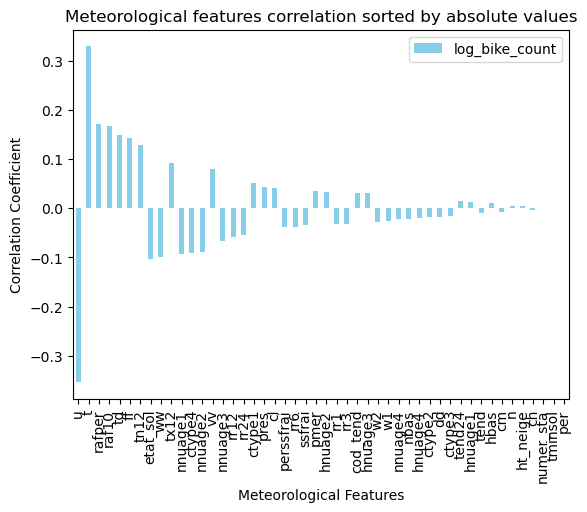

In [19]:
import matplotlib.pyplot as plt

# Sort correlations
target_correlations_sorted = target_correlations.sort_values(
    by="log_bike_count", key=lambda x: x.abs(), ascending=False
)

# Bar plot
plt.figure(figsize=(8, 4))
target_correlations_sorted.plot(kind="bar", color="skyblue")
plt.title("Meteorological features correlation sorted by absolute values")
plt.ylabel("Correlation Coefficient")
plt.xlabel("Meteorological Features")
plt.show()

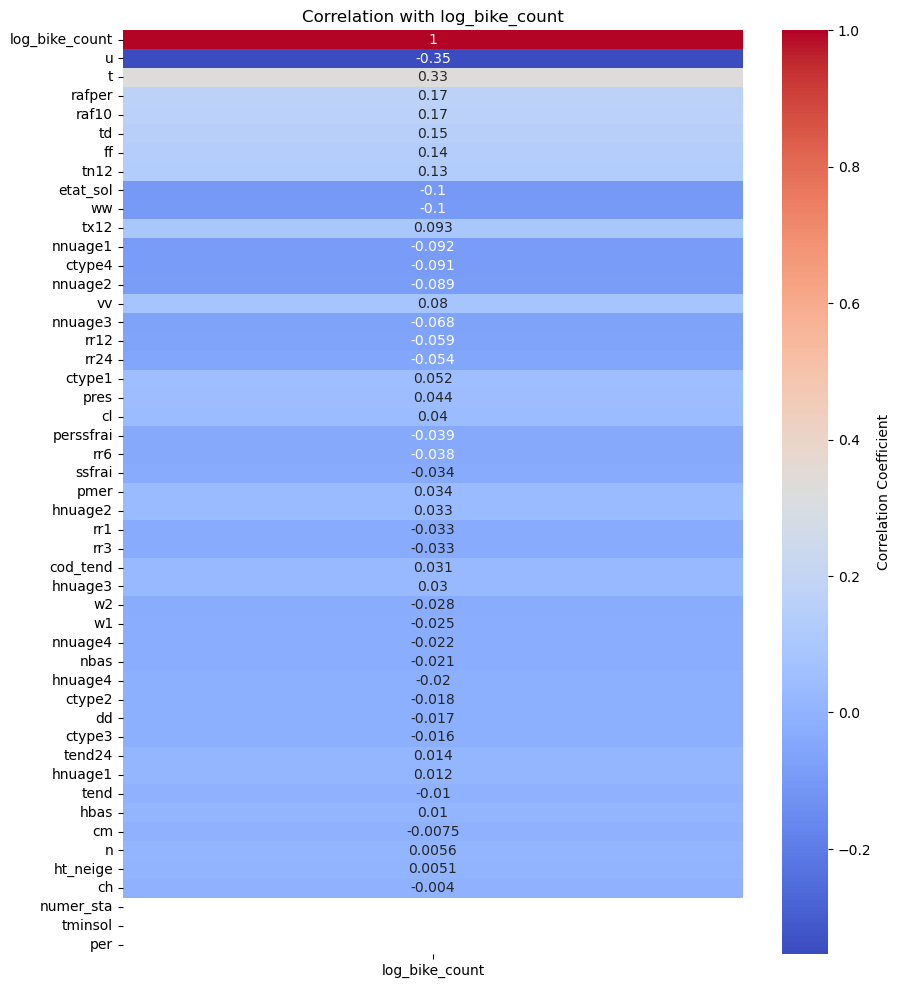

In [27]:
correlation_with_log_bike_count = correlation_matrix[["log_bike_count"]]

# Optionally, you can sort the values if you want to visualize the most correlated features
correlation_with_log_bike_count_sorted = correlation_with_log_bike_count.sort_values(
    by="log_bike_count", key=lambda x: x.abs(), ascending=False
)

# Plotting
plt.figure(figsize=(10, 12))
sns.heatmap(
    correlation_with_log_bike_count_sorted,
    annot=True,
    cmap="coolwarm",
    cbar_kws={"label": "Correlation Coefficient"},
)
plt.title("Correlation with log_bike_count")
plt.show()

In [28]:
correlation_with_log_bike_count_sorted

,log_bike_count
log_bike_count,1.000000
u,-0.354272
t,0.329150
rafper,0.171470
raf10,0.167112
td,0.149101
ff,0.142361
tn12,0.128923
etat_sol,-0.103292
ww,-0.099892


In [30]:
# Maintenant, ne gardons que les features un minimum corrélé avec notre target
data = data.drop(
    columns=[
        "pres",
        "cl",
        "perssfrai",
        "rr6",
        "ssfrai",
        "pmer",
        "hnuage2",
        "rr1",
        "rr3",
        "cod_tend",
        "hnuage3",
        "w2",
        "w1",
        "nnuage4",
        "nbas",
        "hnuage4",
        "ctype2",
        "dd",
        "ctype3",
        "tend24",
        "hnuage1",
        "tend",
        "hbas",
        "cm",
        "n",
        "ht_neige",
        "ch",
        "numer_sta",
        "tminsol",
        "per",
    ]
)